# Requirements

In [121]:
import collections
import functools
import matplotlib.pyplot as plt
import numpy as np
import optuna

# Example 1

## Target function

In [84]:
def func(x, y):
    x_0, y_0 = 5.0, 7.0
    return 1.0 - (np.cos((x - x_0)*(y - y_0))*np.exp(-0.05*((x - x_0)**2 + (y - y_0)**2)))

In [85]:
def visualize_func(func):
    x = np.linspace(-10.0, 10.0, 101)
    y = np.linspace(-10.0, 10.0, 101)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    plt.imshow(Z, cmap='Grays');

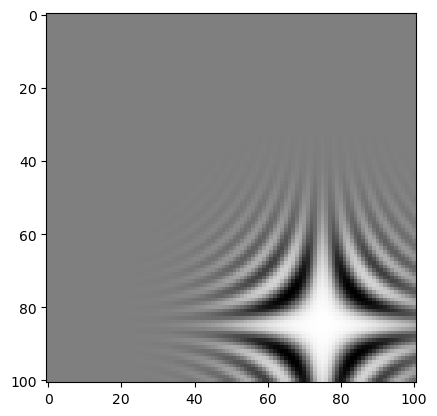

In [86]:
visualize_func(func)

## Optimization

Increase the log level to avoid a flood of info-level messages, i.e., a message per optim

In [69]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

Wrap the function to optimize into an objective function that takes a `trial` object as a parameter.

In [70]:
def objective(trial):
    x = trial.suggest_float('x', -10.0, 10.0)
    y = trial.suggest_float('y', -10.0, 10.0)
    return func(x, y)

Set up a study.

In [71]:
study = optuna.create_study(direction='minimize')

Use the study to optimize the parameters, `x` and `y` in this case.

In [72]:
study.optimize(objective, n_trials=500)

Display the best value and the corresponding values of the parameters `x` and `y`.

In [73]:
print(f'  Value: {study.best_trial.value}')
print('  Params:')
for key, value in study.best_trial.params.items():
    print(f'    {key}: {value}')

  Value: 0.0003461049669315486
  Params:
    x: 4.967603273980602
    y: 7.076241340970131


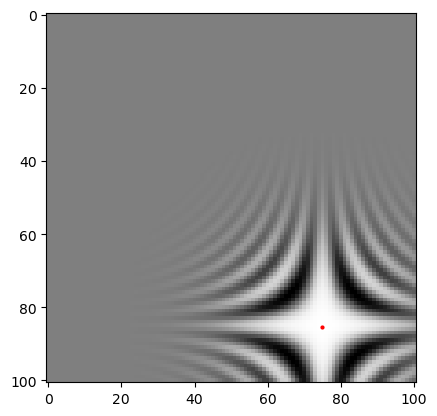

In [74]:
plt.imshow(Z, cmap='Grays')
plt.plot(
    [5.0*study.best_trial.params['x'] + 50.0],
    [5.0*study.best_trial.params['y'] + 50.0],
    'ro',
    markersize=2
);

## Robustness

How different are results of independent runs of the optimization mechanism.

In [79]:
nr_tries = 10
xs, ys = [], []
for _ in range(nr_tries):
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=100)
    xs.append(study.best_trial.params['x'])
    ys.append(study.best_trial.params['y'])

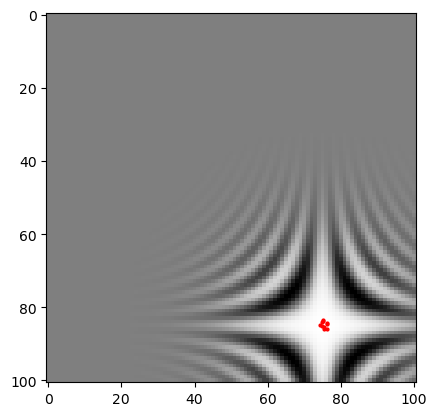

In [80]:
plt.imshow(Z, cmap='Grays')
plt.plot(
    [5.0*x + 50.0 for x in xs],
    [5.0*y + 50.0 for y in ys],
    'ro',
    markersize=2
);

# Example 2

## Target function

In [106]:
def gauss_holes(x, y, holes):
    x_1, y_1, a_1, s_1 = holes[0][0], holes[0][1], 7.0, 0.05
    x_2, y_2, a_2, s_2 = holes[1][0], holes[1][1], 10.0, 0.5
    g_1 = a_1*np.exp(-s_1*((x - x_1)**2 + (y - y_1)**2))
    g_2 = a_2*np.exp(-s_2*((x - x_2)**2 + (y - y_2)**2))
    return 10.0 - g_1 - g_2

In [113]:
holes = [(-3.0, 5.0), (7.0, -3.0)]

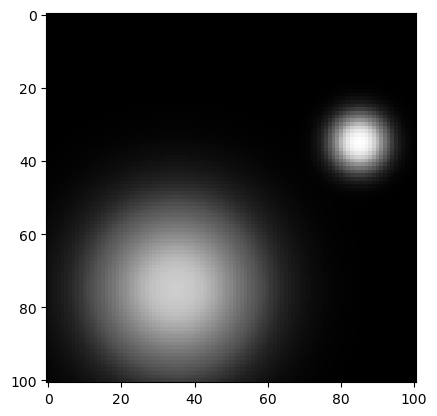

In [114]:
visualize_func(functools.partial(gauss_holes, holes=holes))

## Samplers

### Default

In [170]:
nr_tries = 20
xs, ys = [], []
for _ in range(nr_tries):
    study = optuna.create_study(direction='minimize')
    study.optimize(
        lambda trial: functools.partial(
            gauss_holes,
            holes=holes)(trial.suggest_float('x', -10.0, 10.0), trial.suggest_float('y', -10.0, 10.0)),
        n_trials=200
    )
    xs.append(study.best_trial.params['x'])
    ys.append(study.best_trial.params['y'])

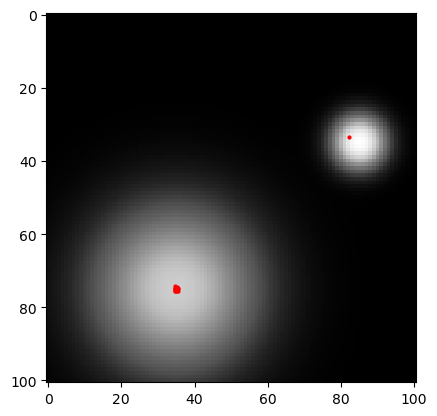

In [171]:
visualize_func(functools.partial(gauss_holes, holes=holes))
plt.plot(
    [5.0*x + 50.0 for x in xs],
    [5.0*y + 50.0 for y in ys],
    'ro',
    markersize=2
);

In [180]:
counter = collections.Counter()
for x, y in zip(xs, ys):
    if np.isclose(x, holes[0][0], atol=3.0) and np.isclose(y, holes[0][1], atol=3.0):
        counter[holes[0]] += 1
    elif np.isclose(x, holes[1][0], atol=0.1) and np.isclose(y, holes[1][1], atol=0.1):
        counter[holes[1]] += 1
counter

Counter({(-3.0, 5.0): 19})

### TPESampler

In [181]:
nr_tries = 20
xs, ys = [], []
for _ in range(nr_tries):
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())
    study.optimize(
        lambda trial: functools.partial(
            gauss_holes,
            holes=holes)(trial.suggest_float('x', -10.0, 10.0), trial.suggest_float('y', -10.0, 10.0)),
        n_trials=200
    )
    xs.append(study.best_trial.params['x'])
    ys.append(study.best_trial.params['y'])

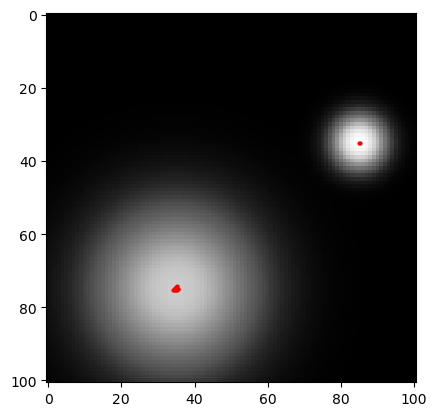

In [182]:
visualize_func(functools.partial(gauss_holes, holes=holes))
plt.plot(
    [5.0*x + 50.0 for x in xs],
    [5.0*y + 50.0 for y in ys],
    'ro',
    markersize=2
);

In [183]:
counter = collections.Counter()
for x, y in zip(xs, ys):
    if np.isclose(x, holes[0][0], atol=3.0) and np.isclose(y, holes[0][1], atol=3.0):
        counter[holes[0]] += 1
    elif np.isclose(x, holes[1][0], atol=0.1) and np.isclose(y, holes[1][1], atol=0.1):
        counter[holes[1]] += 1
counter

Counter({(-3.0, 5.0): 18, (7.0, -3.0): 2})

### RandomSampler

In [184]:
nr_tries = 20
xs, ys = [], []
for _ in range(nr_tries):
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.RandomSampler())
    study.optimize(
        lambda trial: functools.partial(
            gauss_holes,
            holes=holes)(trial.suggest_float('x', -10.0, 10.0), trial.suggest_float('y', -10.0, 10.0)),
        n_trials=200
    )
    xs.append(study.best_trial.params['x'])
    ys.append(study.best_trial.params['y'])

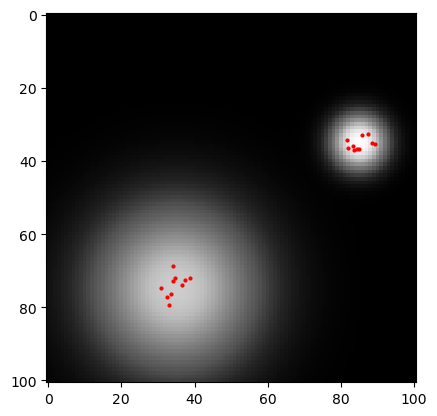

In [185]:
visualize_func(functools.partial(gauss_holes, holes=holes))
plt.plot(
    [5.0*x + 50.0 for x in xs],
    [5.0*y + 50.0 for y in ys],
    'ro',
    markersize=2
);

In [186]:
counter = collections.Counter()
for x, y in zip(xs, ys):
    if np.isclose(x, holes[0][0], atol=3.0) and np.isclose(y, holes[0][1], atol=3.0):
        counter[holes[0]] += 1
    elif np.isclose(x, holes[1][0], atol=0.1) and np.isclose(y, holes[1][1], atol=0.1):
        counter[holes[1]] += 1
counter

Counter({(-3.0, 5.0): 10})